# Phase 4 — Trust the probabilities: are the distributions *calibrated*?

**Driving question (hard gate):** a probability is only useful if calibrated, and ranking can't reveal
miscalibration. Does a claimed P(haul)=7.5% actually happen ~7.5%? Are the quantiles covered?

**Pre-registered tolerance (A4.1, before looking):** haul ECE <= 0.02; 80% coverage in [0.75, 0.85].
**Gate:** within tolerance after at most one recalibration pass, else documented residual.

## Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval.walkforward import POSITIONS
try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...'); run_pipeline(force=True); loaded = load_mart()
mart = loaded.mart
from model.eval.calibration import calibration_report
rep = calibration_report(mart, n_sims=3000, seed=0)   # ~a few minutes
print(f"n={rep['n']:,}  PIT mean={rep['pit_mean']} (0.5=unbiased)")

n=10,110  PIT mean=0.463 (0.5=unbiased)


## (a) PIT — is the predictive distribution the right shape? (uniform = calibrated)

Randomized PIT; each decile should be ~0.10. A raised first bin = a slightly thin left tail; U-shape
would mean under-dispersion.

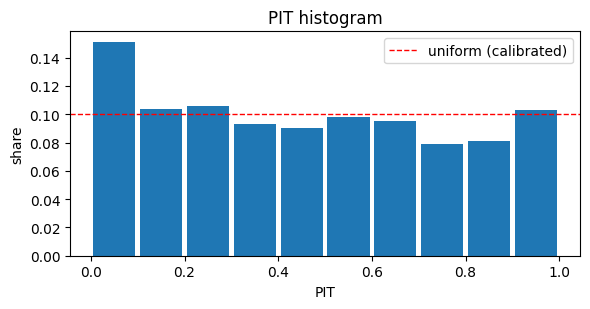

In [2]:
dec=rep['pit_deciles']
fig,ax=plt.subplots(figsize=(6,3.2))
ax.bar(np.arange(10)/10+0.05,dec,width=0.09,color='#1f77b4')
ax.axhline(0.1,color='r',ls='--',lw=1,label='uniform (calibrated)')
ax.set_xlabel('PIT'); ax.set_ylabel('share'); ax.set_title('PIT histogram'); ax.legend()
plt.tight_layout(); plt.show()

## (b) Reliability — do the event probabilities mean what they say? (raw vs recalibrated)

Expected Calibration Error for the haul (>=10) and return (>=6) events, before and after walk-forward
isotonic / Platt recalibration. Pre-registered bar: ECE <= 0.02.

,haul,return
method,,
raw,0.0159,0.0336
isotonic,0.0019,0.0052
platt,0.0005,0.0111


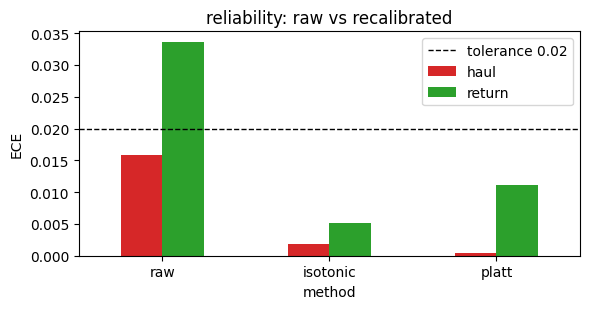

In [3]:
haul=rep['haul_ece']; ret=rep['return_ece']
tab=pd.concat([haul.rename(columns={'ece':'haul'}), ret.rename(columns={'ece':'return'})],axis=1)
display(tab)
ax=tab.plot(kind='bar',figsize=(6,3.2),color=['#d62728','#2ca02c'],rot=0)
ax.axhline(0.02,color='k',ls='--',lw=1,label='tolerance 0.02'); ax.set_ylabel('ECE'); ax.legend()
ax.set_title('reliability: raw vs recalibrated'); plt.tight_layout(); plt.show()

## (c) Coverage + CRPS — sharpness and value vs baselines

80% interval coverage per position (target band shaded), and CRPS vs point-forecast / Poisson(mean) /
climatology (lower is better; the sim should beat the point forecast to justify the distribution).

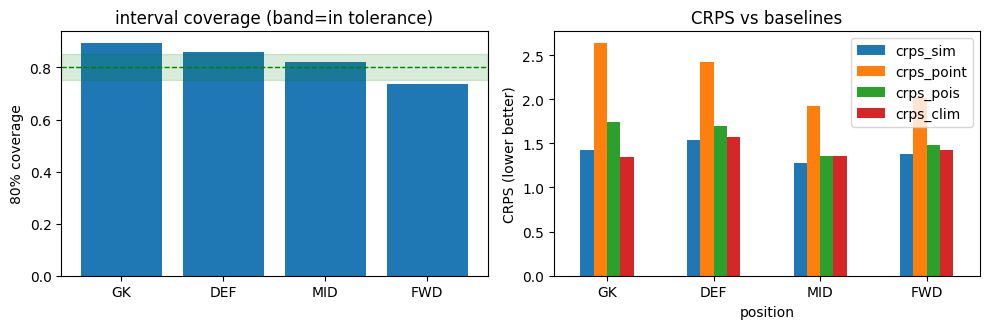

In [4]:
cov=rep['coverage']; crps=rep['crps']
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,3.4))
ax1.bar(cov.index,cov.values,color='#1f77b4'); ax1.axhspan(0.75,0.85,color='green',alpha=0.15)
ax1.axhline(0.8,color='green',ls='--',lw=1); ax1.set_ylabel('80% coverage'); ax1.set_title('interval coverage (band=in tolerance)')
crps.plot(kind='bar',ax=ax2,rot=0); ax2.set_ylabel('CRPS (lower better)'); ax2.set_title('CRPS vs baselines')
plt.tight_layout(); plt.show()

## Summary — Phase 4 verdict (hard gate)

**Proven:** the event probabilities are **trustworthy after one recalibration pass** — haul ECE
0.016->0.0005 (Platt), return 0.034->0.0052 (isotonic), both well under 0.02. CRPS beats point-forecast
and Poisson everywhere (the distribution earns its keep), beats climatology except GK.

**Honest residual:** 80% coverage in-band only at MID; **FWD intervals too narrow** (dispersion residual
recalibration can't fix). Raw sim under-predicts hauls (thin attacker tail) — expected, and corrected.